In [1]:
import pandas as pd 
import numpy as np
from collections import defaultdict

In [2]:
import sys
sys.path.append('/Users/fido_josephine/Documents/New-Fraud-Rules/fraud')
from modules.distance_finder import lev_win_multi, lev_win

In [3]:
df = pd.read_csv('/Users/fido_josephine/Documents/New-Fraud-Rules/Data/surveys (1).csv')
df['SURVEY_DATE'] = pd.to_datetime(df['SURVEY_DATE'])

In [7]:
sample = df.head(2000)

In [9]:
sample

,HASH,CLIENT_ID,SURVEY_WEEK,SURVEY_DATE,ADDRESS,EMAIL,POSITION,DISB_DATE,INDUSTRY,DISBURSED,DR1,DEFAULTED,PTFRAUD
0,ecpb0,178484003,2024-02-05,2024-02-05 09:36:39,Peace church,acquahmary574@gmail.com,Packaging,2024-02-05 09:40:44.000,Food Industry,1,0,0,0
1,NaN,844806159,2024-01-29,2024-01-30 23:10:06,GBC bank,hensy.ai@gmail.com,Owner,2024-01-30 23:29:41.000,Transportation,1,0,0,0
2,ecpb1,832139937,2024-01-22,2024-01-27 17:15:06,ATTA MILLS,arhinm220@gmail.com,DRIVER,2025-02-06 11:16:37.000,Transportation,1,0,1,0
3,ecy1p,279135133,2024-03-04,2024-03-05 21:10:31,old karaga street,NaN,accountant,2024-03-05 21:21:50.000,Healthcare,1,0,0,0
4,ebzze,368413062,2024-03-04,2024-03-06 19:42:23,Abebrese Street,dadzitheodora77@gmail.com,nurse,2024-03-19 08:52:37.000,Healthcare,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1995,ecnz3,85359403,2024-03-04,2024-03-06 15:36:23,Maame lucy street Asamankama,acheamponghubert1001@gmail.com,To help communicate easily and easy,2024-03-06 15:41:20.000,Media and Communications,1,0,0,0
1996,ebzze,43068710,2024-01-29,2024-01-31 10:44:45,Amerley laryer Street,arthurabi83@gmail.com,customer Care personnel,2024-01-31 10:58:11.000,Security,1,0,0,0
1997,ecpbr,461030000,2024-01-29,2024-01-31 11:57:35,akorfa street,NaN,i am the Claims officer there,2024-01-31 20:19:43.000,Healthcare,1,0,0,0
1998,ebzxn,830703657,2024-01-29,2024-01-30 18:51:18,JB Brew Clinic,NaN,security guard,2024-01-30 18:52:36.000,Security,1,1,0,1


In [11]:
sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   HASH         1720 non-null   object        
 1   CLIENT_ID    2000 non-null   int64         
 2   SURVEY_WEEK  2000 non-null   object        
 3   SURVEY_DATE  2000 non-null   datetime64[ns]
 4   ADDRESS      2000 non-null   object        
 5   EMAIL        1262 non-null   object        
 6   POSITION     1919 non-null   object        
 7   DISB_DATE    2000 non-null   object        
 8   INDUSTRY     1919 non-null   object        
 9   DISBURSED    2000 non-null   int64         
 10  DR1          2000 non-null   int64         
 11  DEFAULTED    2000 non-null   int64         
 12  PTFRAUD      2000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(7)
memory usage: 203.3+ KB


Iterating over multiple similarity threholds

In [14]:
records = []
for i in range(2, 5):
    output = defaultdict(list) 
    res = lev_win(df, 15, 3, i)
    output['sim_threshold'] = i
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)


In [15]:
output1 = pd.DataFrame(records)

In [16]:
output1

,sim_threshold,n_surveys,n_disbursed,dr
0,2,1538,817,0.249694
1,3,2010,1034,0.255319
2,4,3795,1882,0.232200


In [ ]:
records = []
for i in range(2, 6):
    output = defaultdict(list) 
    res = lev_win(df, 15, i, 3)
    output['dup_limit'] = i
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)



In [19]:
output2 = pd.DataFrame(records)

In [20]:
output2

,dup_limit,n_surveys,n_disbursed,dr
0,2,3982,2005,0.248878
1,3,2010,1034,0.255319
2,4,1188,637,0.244898
3,5,777,416,0.230769


In [21]:
records = []
for i in range(3, 6):
    output = defaultdict(list) 
    res = lev_win(df, 15, i, 4)
    output['dup_limit'] = i
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

In [22]:
output3 = pd.DataFrame(records)
output3

,dup_limit,n_surveys,n_disbursed,dr
0,3,3795,1882,0.232200
1,4,2253,1132,0.226148
2,5,1409,730,0.216438


MultiColumn Duplications Iterations

In [24]:
#iterating over range for position similarity
records = []
for i in range(3, 6):
    output = defaultdict(list) 
    res = lev_win_multi(df, 15, 3, i, 2)
    output['dup_limit'] = i
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

In [25]:
output4 = pd.DataFrame(records)
output4

,dup_limit,n_surveys,n_disbursed,dr
0,3,79,45,0.511111
1,4,66,39,0.615385
2,5,99,56,0.464286


In [26]:
#iterating over range for dup threshold 
records = []
for i in range(2, 6):
    output = defaultdict(list) 
    res = lev_win_multi(df, 15, 3, 4, i)
    output['dup_limit'] = i
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)

output5 = pd.DataFrame(records)
output5

,dup_limit,n_surveys,n_disbursed,dr
0,2,66,39,0.615385
1,3,30,15,0.733333
2,4,17,8,0.875000
3,5,12,6,0.833333


In [27]:
#iterating over range for position similarity
records = []
for i in range(2, 7):
    output = defaultdict(list) 
    res = lev_win_multi(df, 15, 3, i, 2)
    output['dup_limit'] = i
    output['n_surveys'] = res['CLIENT_ID'].count()
    output['n_disbursed'] = res['DISBURSED'].sum()
    output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
    records.append(output)


output6 = pd.DataFrame(records)
output6

,dup_limit,n_surveys,n_disbursed,dr
0,2,57,33,0.636364
1,3,79,45,0.511111
2,4,66,39,0.615385
3,5,99,56,0.464286
4,6,43,24,0.625000


In [28]:
records = []
for i in range(2, 7):
    for j in range(2,6):
        output = defaultdict(list) 
        res = lev_win_multi(df, 15, 3, i, j)
        output['pos_sim'] = i
        output['dup_limit'] = j
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output7 = pd.DataFrame(records)
output7

,pos_sim,dup_limit,n_surveys,n_disbursed,dr
0,2,2,57,33,0.636364
1,2,3,31,15,0.733333
2,2,4,18,8,0.875000
3,2,5,10,4,0.750000
4,3,2,79,45,0.511111
5,3,3,35,17,0.647059
6,3,4,21,9,0.777778
7,3,5,12,4,0.750000
8,4,2,66,39,0.615385
9,4,3,30,15,0.733333


In [29]:
import matplotlib.pyplot as plt

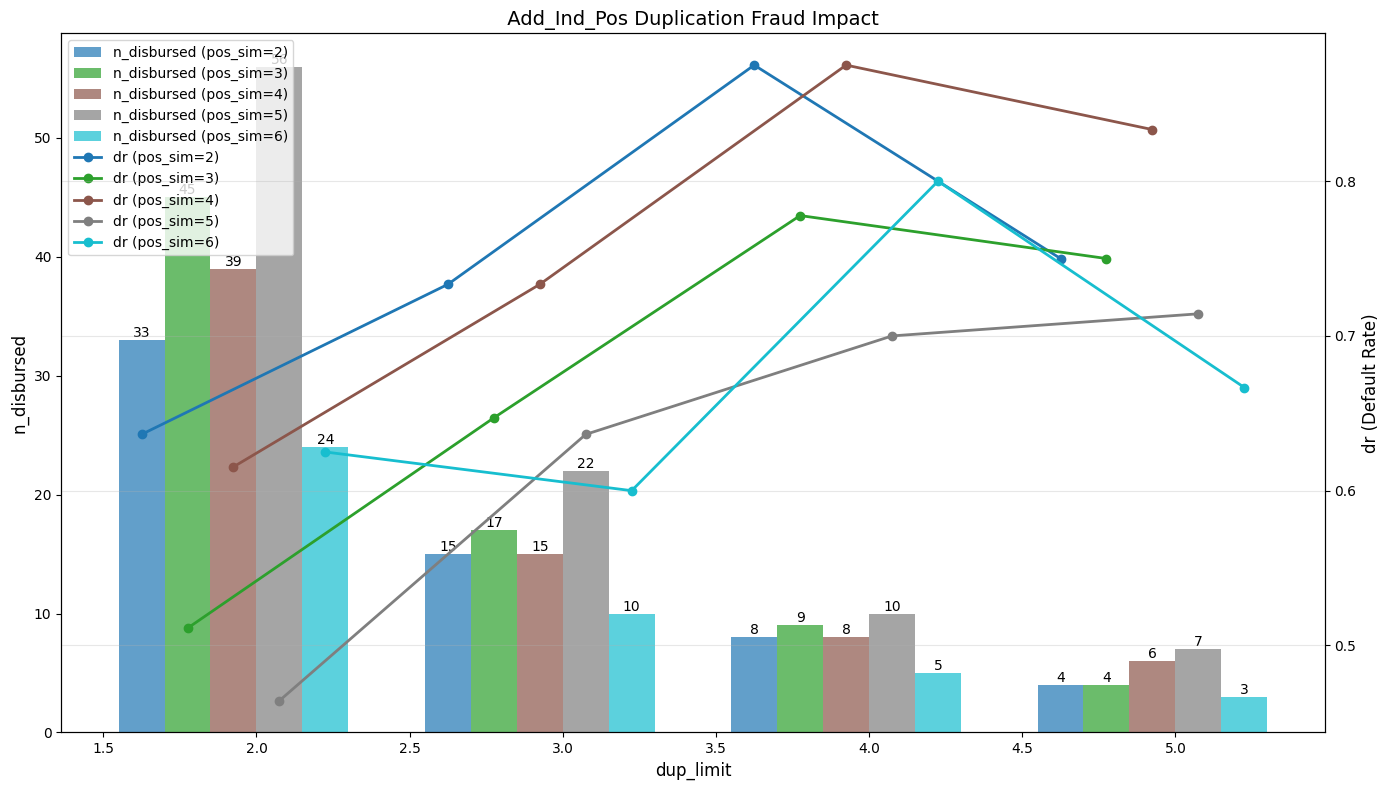

In [37]:
# Create the plot

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Define a colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(output7['pos_sim'].unique())))
color_dict = {val: colors[i] for i, val in enumerate(sorted(output7['pos_sim'].unique()))}

# Plot bars and lines for each pos_sim value
for i, pos_sim in enumerate(sorted(output7['pos_sim'].unique())):
    subset = output7[output7['pos_sim'] == pos_sim]
    
    # Add slight offset to x positions for each pos_sim to avoid overlap
    width = 0.15
    offset = (i - len(output7['pos_sim'].unique())/2) * width
    
    # Plot n_disbursed as bars
    bars = ax1.bar(subset['dup_limit'] + offset, subset['n_disbursed'], 
                  width=width, color=color_dict[pos_sim], alpha=0.7,
                  label=f'n_disbursed (pos_sim={pos_sim})')
    
    # Plot dr as lines with markers
    line = ax2.plot(subset['dup_limit'] + offset, subset['dr'], 
                   linestyle='-', marker='o', color=color_dict[pos_sim],
                   alpha=1.0, linewidth=2,
                   label=f'dr (pos_sim={pos_sim})')
    for bar in bars: 
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height}', ha='center', va='bottom', fontsize=10, color='black')


# Set labels and title
ax1.set_xlabel('dup_limit', fontsize=12)
ax1.set_ylabel('n_disbursed', fontsize=12, color='black')
ax2.set_ylabel('dr (Default Rate)', fontsize=12, color='black')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Set title
plt.title(' Add_Ind_Pos Duplication Fraud Impact ', fontsize=14)

# Adjust layout and display
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()

In [39]:
records = []
for i in range(3, 6):
    for j in range(2, 5):
        output = defaultdict(list) 
        res = lev_win(df, 15, i, j)
        output['dup_limit'] = i
        output['n_surveys'] = res['CLIENT_ID'].count()
        output['n_disbursed'] = res['DISBURSED'].sum()
        output['dr'] = res['DR1'].sum()/res['DISBURSED'].sum()
        records.append(output)


output8 = pd.DataFrame(records)

In [40]:
output8

,dup_limit,n_surveys,n_disbursed,dr
0,3,1538,817,0.249694
1,3,2010,1034,0.255319
2,3,3795,1882,0.232200
3,4,947,524,0.253817
4,4,1188,637,0.244898
5,4,2253,1132,0.226148
6,5,655,356,0.241573
7,5,777,416,0.230769
8,5,1409,730,0.216438


In [ ]:
# Create the plot

fig, ax1 = plt.subplots(figsize=(14, 8))
ax2 = ax1.twinx()

# Define a colormap
colors = plt.cm.tab10(np.linspace(0, 1, len(output7['pos_sim'].unique())))
color_dict = {val: colors[i] for i, val in enumerate(sorted(output7['pos_sim'].unique()))}

# Plot bars and lines for each pos_sim value
for i, pos_sim in enumerate(sorted(output7['pos_sim'].unique())):
    subset = output7[output7['pos_sim'] == pos_sim]
    
    # Add slight offset to x positions for each pos_sim to avoid overlap
    width = 0.15
    offset = (i - len(output7['pos_sim'].unique())/2) * width
    
    # Plot n_disbursed as bars
    bars = ax1.bar(subset['dup_limit'] + offset, subset['n_disbursed'], 
                  width=width, color=color_dict[pos_sim], alpha=0.7,
                  label=f'n_disbursed (pos_sim={pos_sim})')
    
    # Plot dr as lines with markers
    line = ax2.plot(subset['dup_limit'] + offset, subset['dr'], 
                   linestyle='-', marker='o', color=color_dict[pos_sim],
                   alpha=1.0, linewidth=2,
                   label=f'dr (pos_sim={pos_sim})')
    for bar in bars: 
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width()/2, height, f'{height}', ha='center', va='bottom', fontsize=10, color='black')


# Set labels and title
ax1.set_xlabel('dup_limit', fontsize=12)
ax1.set_ylabel('n_disbursed', fontsize=12, color='black')
ax2.set_ylabel('dr (Default Rate)', fontsize=12, color='black')

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', fontsize=10)

# Set title
plt.title(' Add_Ind_Pos Duplication Fraud Impact ', fontsize=14)

# Adjust layout and display
plt.tight_layout()
plt.grid(True, alpha=0.3)
plt.show()